In [ ]:
!pwd

/content


In [1]:
!git clone https://github.com/challasivaramya/Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026.git


Cloning into 'Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 66 (delta 25), reused 51 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 1.52 MiB | 4.98 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [5]:
%cd Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026/week-1/assignment/

/content/Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026/week-1/assignment


In [13]:
%pwd

'/content/Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026/week-1/assignment'

In [15]:
%%writefile q1.py
import numpy as np

def gram_schmidt(A: np.ndarray) -> np.ndarray:
    A=A.T
    U=np.zeros_like(A,dtype=float)
    n=A.shape[0]
    for i in range(n):
        v=A[i]
        if i>0:
            s=np.sum(((np.sum(v*U[:i],axis=1)/np.sum(U[:i]*U[:i],axis=1)).reshape(-1,1))*U[:i],axis=0)
            U[i]=v-s
        else:
            U[i]=v
    norm=np.linalg.norm(U,axis=1)
    Q=(U/norm[:,None]).T
    return Q

Overwriting q1.py


In [6]:
import pandas as pd

df=pd.read_pickle("submission_data.pkl")

In [23]:
!pip install pandas

In [2]:
!pip install pandas==3.0.2


In [3]:
%pwd


'/content'

In [29]:
%cd /content/Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026/week-1/assignment/

/content/Graph-Neural-Networks-and-Recommendation-Systems-SOC-2026/week-1/assignment


In [16]:
print(df.shape)
print(df.dtypes.unique())
print((df.isnull().sum()).isnull().sum())
print(df.columns)

(1618, 107)
[dtype('int64') dtype('<M8[us]') dtype('float64')]
0
Index(['Sno', 'Lecture', 'StudentNo', 'Total_Characters', 'Total_Words',
       'Submission_Time', 'x_01', 'x_02', 'x_03', 'x_04',
       ...
       'x_92', 'x_93', 'x_94', 'x_95', 'x_96', 'x_97', 'x_98', 'x_99', 'x_100',
       'target'],
      dtype='str', length=107)


In [10]:
df["target"]=(df["Submission_Delay"]>0).astype(int)
df=df.drop(columns=["Submission_Delay"])
X=df.drop(columns=["target"])
y=df["target"]
print(y.value_counts())
print(X.shape)

target
0    1398
1     220
Name: count, dtype: int64
(1618, 106)


/tmp/ipykernel_7745/2852288084.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"]=(df["Submission_Delay"]>0).astype(int)


In [17]:
for col in X.columns:
    print(col, X[col].nunique())

Sno 1618
Lecture 11
StudentNo 195
Total_Characters 1269
Total_Words 579
Submission_Time 1570
x_01 1615
x_02 1615
x_03 1615
x_04 1613
x_05 1615
x_06 1615
x_07 1615
x_08 1615
x_09 1615
x_10 1615
x_11 1615
x_12 1615
x_13 1615
x_14 1615
x_15 1615
x_16 1615
x_17 1615
x_18 1615
x_19 1615
x_20 1615
x_21 1615
x_22 1615
x_23 1615
x_24 1615
x_25 1615
x_26 1615
x_27 1615
x_28 1615
x_29 1615
x_30 1615
x_31 1615
x_32 1615
x_33 1615
x_34 1615
x_35 1615
x_36 1615
x_37 1615
x_38 1615
x_39 1615
x_40 1615
x_41 1615
x_42 1615
x_43 1615
x_44 1614
x_45 1615
x_46 1615
x_47 1615
x_48 1615
x_49 1615
x_50 1615
x_51 1615
x_52 1615
x_53 1615
x_54 1615
x_55 1615
x_56 1615
x_57 1615
x_58 1615
x_59 1615
x_60 1615
x_61 1615
x_62 1615
x_63 1615
x_64 1615
x_65 1615
x_66 1615
x_67 1614
x_68 1615
x_69 1614
x_70 1615
x_71 1615
x_72 1615
x_73 1614
x_74 1615
x_75 1615
x_76 1615
x_77 1615
x_78 1615
x_79 1615
x_80 1615
x_81 1615
x_82 1615
x_83 1615
x_84 1615
x_85 1615
x_86 1615
x_87 1615
x_88 1615
x_89 1615
x_90 1615
x_91 16

In [18]:
from sklearn.preprocessing import StandardScaler

feature_columns=[c for c in X.columns if c.startswith("x_")]
feature_columns+=["Total_Words","Total_Characters"]

scaler=StandardScaler()

X_scaled=X.copy()

X_scaled[feature_columns]=scaler.fit_transform(
    X[feature_columns]
)

Top 15 features:
x_04                0.065493
x_05                0.060733
x_54                0.057554
Total_Words         0.055027
Total_Characters    0.053349
x_74                0.047948
x_84                0.046002
x_19                0.044380
x_52                0.043613
x_25                0.039566
x_100               0.039395
x_38                0.036348
x_02                0.035862
x_86                0.035243
x_48                0.035191
dtype: float64


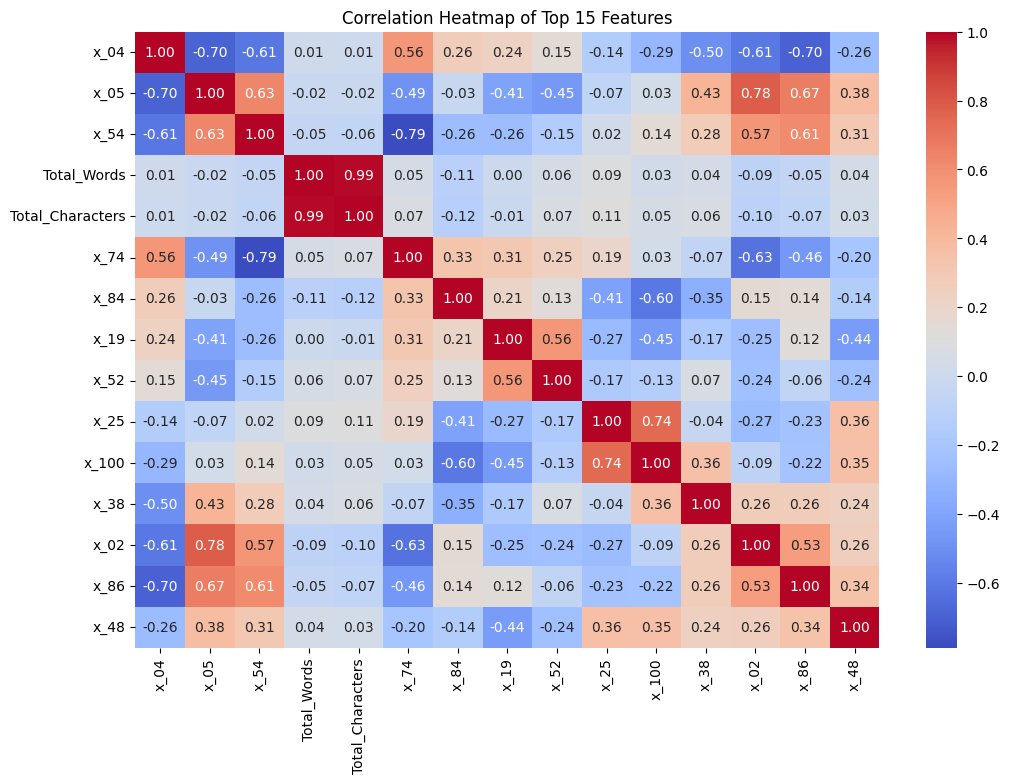

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr=X_scaled[feature_columns].corrwith(y)

top15=corr.abs().sort_values(
    ascending=False
).head(15)

top15_features=top15.index.tolist()

print("Top 15 features:")
print(top15)

corr_matrix=X_scaled[top15_features].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top 15 Features")
plt.show()

In [22]:
%%writefile summary.md

## Part 2
## Phase 2: Heatmap Analysis

Correlation values range from -1 to 1.

- Positive values mean both features increase together.
- Negative values mean one feature increases while the other decreases.
- Values near 0 mean weak relation.

From the heatmap:

- Total_Words and Total_Characters have very high correlation (0.99), so they contain almost the same information.
- x_05 and x_02 have strong positive correlation (0.78).
- x_25 and x_100 have strong positive correlation (0.74).
- x_54 and x_74 have strong negative correlation (-0.79).

This shows the presence of multicollinearity, where multiple features carry similar information.

Multicollinearity can create redundancy because highly related features provide similar patterns. This can make some models less stable and increase unnecessary complexity.

Overwriting summary.md


In [23]:
!pip install umap-learn

In [24]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

In [25]:
X_all=X_scaled[feature_columns+["Total_Words","Total_Characters"]]

X_top15=X_scaled[top15_features]

tsne_all=TSNE(
    n_components=2,
    random_state=42
)

X_tsne_all=tsne_all.fit_transform(X_all)

umap_all=umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap_all=umap_all.fit_transform(X_all)

tsne_top15=TSNE(
    n_components=2,
    random_state=42
)

X_tsne_top15=tsne_top15.fit_transform(X_top15)

umap_top15=umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap_top15=umap_top15.fit_transform(X_top15)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


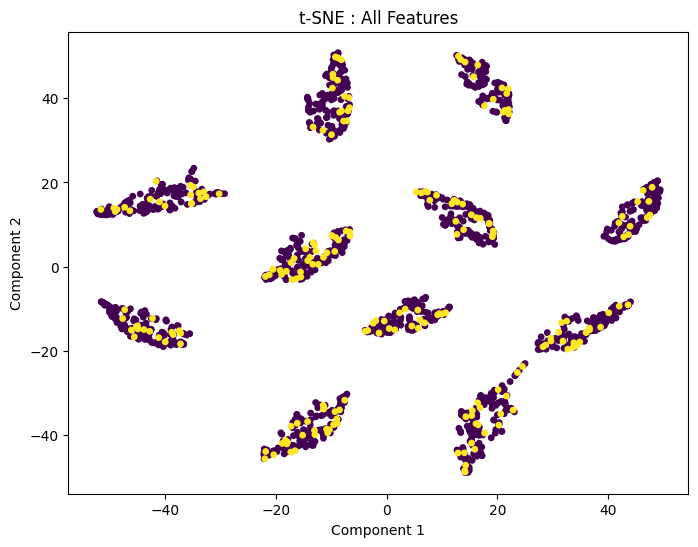

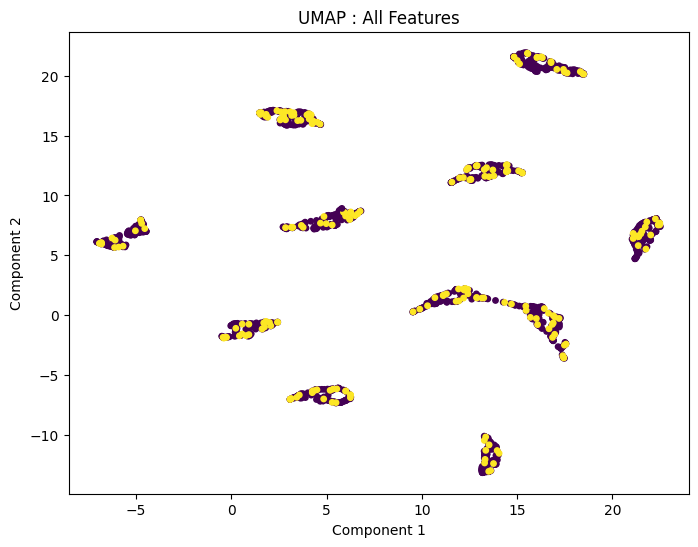

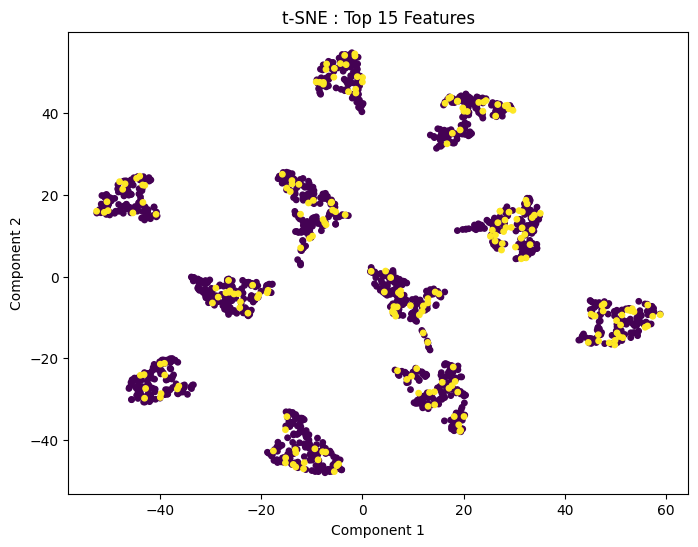

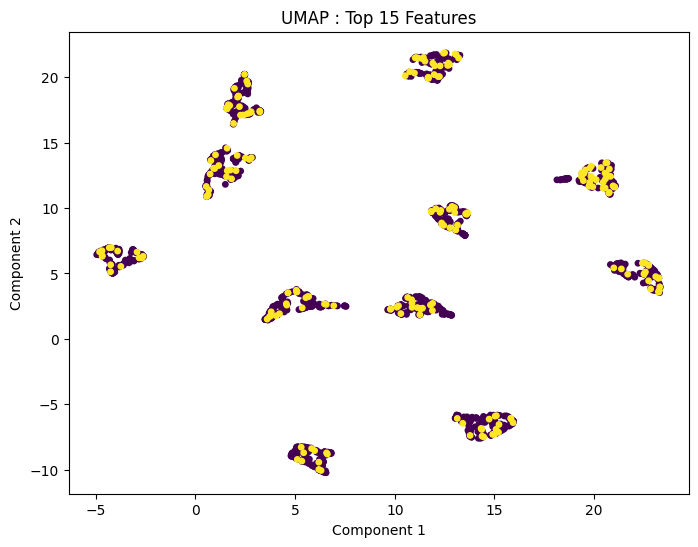

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne_all[:,0],
    X_tsne_all[:,1],
    c=y,
    s=15
)
plt.title("t-SNE : All Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    X_umap_all[:,0],
    X_umap_all[:,1],
    c=y,
    s=15
)
plt.title("UMAP : All Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne_top15[:,0],
    X_tsne_top15[:,1],
    c=y,
    s=15
)
plt.title("t-SNE : Top 15 Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    X_umap_top15[:,0],
    X_umap_top15[:,1],
    c=y,
    s=15
)
plt.title("UMAP : Top 15 Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [31]:
%%writefile -a summary.md

## Phase 3: t-SNE and UMAP Analysis

UMAP produced a more compact and visually organized representation of the data. Since UMAP is designed to preserve larger relationships in the data, it may preserve the overall structure better than t-SNE.

Late and on-time submissions do not form clearly separated clusters. Both classes appear mixed within the same regions, which suggests that the features do not naturally separate the two classes.

Comparing all features with the top 15 features, the top 15 feature plots show slightly more compact local grouping, but the overall clustering pattern remains similar. This suggests that reducing the number of features had only a small effect on the data structure.

Appending to summary.md


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score

In [33]:
X=X_scaled[top15_features]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Support Vector Machine (SVC)":SVC(probability=True),
    "Random Forest Classifier":RandomForestClassifier(random_state=42)
}
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    report=classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    auc=roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model":name,
        "Accuracy":report["accuracy"],
        "Precision (Class 1)":report["1"]["precision"],
        "Recall (Class 1)":report["1"]["recall"],
        "F1-Score (Class 1)":report["1"]["f1-score"],
        "AUC_ROC":auc
    })
results_df=pd.DataFrame(results)
results_df
print(results_df.to_markdown(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

| Model                        |   Accuracy |   Precision (Class 1) |   Recall (Class 1) |   F1-Score (Class 1) |   AUC_ROC |
|:-----------------------------|-----------:|----------------------:|-------------------:|---------------------:|----------:|
| Logistic Regression          |   0.864198 |                     0 |                  0 |                    0 |  0.490422 |
| Support Vector Machine (SVC) |   0.864198 |                     0 |                  0 |                    0 |  0.402841 |
| Random Forest Classifier     |   0.851852 |                     0 |                  0 |                    0 |  0.484537 |


In [36]:
X_all=X_scaled.select_dtypes(
    include=["int64","float64"]
)
X_train,X_test,y_train,y_test=train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
results_all=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    report=classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    auc=roc_auc_score(
        y_test,
        y_prob
    )
    results_all.append({
        "Model":name,
        "Accuracy":report["accuracy"],
        "Precision (Class 1)":report["1"]["precision"],
        "Recall (Class 1)":report["1"]["recall"],
        "F1-Score (Class 1)":report["1"]["f1-score"],
        "AUC_ROC":auc
    })
results_all_df=pd.DataFrame(results_all)
results_all_df
print(results_all_df.to_markdown(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

| Model                        |   Accuracy |   Precision (Class 1) |   Recall (Class 1) |   F1-Score (Class 1) |   AUC_ROC |
|:-----------------------------|-----------:|----------------------:|-------------------:|---------------------:|----------:|
| Logistic Regression          |   0.950617 |                  1    |           0.636364 |             0.777778 |  0.987906 |
| Support Vector Machine (SVC) |   0.864198 |                  0    |           0        |             0        |  0.714367 |
| Random Forest Classifier     |   0.876543 |                  0.75 |           0.136364 |             0.230769 |  0.899351 |
